In [2]:
from importlib import import_module
import os
import sys
import argparse
import linecache
import uproot
import vector
import math
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
from tqdm import tqdm  # ✅ 진행률 표시
import glob
import json
import uproot
vector.register_awkward()

In [4]:

sample = "/gv0/Users/achihwan/SKNano/Run3NanoAODv12/2023/WRtoNMutoMuMuJJ_MWR2000_N100_TuneCP5_13p6TeV_madgraph-pythia8/NANOAODSIM/130X_mcRun3_2023_realistic_v15-v2/130000/c8f9b760-1932-4a95-b7d5-f836e3bb8b79.root"
file = uproot.open(sample)
events = file["Events"]
runs = file["Runs"]
keys = events.keys()

In [10]:
muon_charge = events["Muon_charge"].array()
muon_tight_charge = events["Muon_tightCharge"].array()

In [17]:
print(muon_charge)
print(muon_tight_charge)

all_tight_charge = ak.flatten(muon_tight_charge)
print(all_tight_charge)
# a는 고유한 값들이 담긴 배열
# b는 각 값이 몇 번 등장했는지 담긴 배열(개수)
a, b = np.unique(all_tight_charge, return_counts=True)
print(a)
print(b)


[[1, -1], [-1, 1], [1, 1, 1], [-1, ...], ..., [1, 1], [1, 1, -1, -1], [-1, 1]]
[[2, 2], [2, 2], [2, 2, 2], [2, 2], ..., [2, ...], [2, 2], [2, 2, 2, 2], [2, 2]]
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ..., 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
[0, 2]
[3458, 190076]


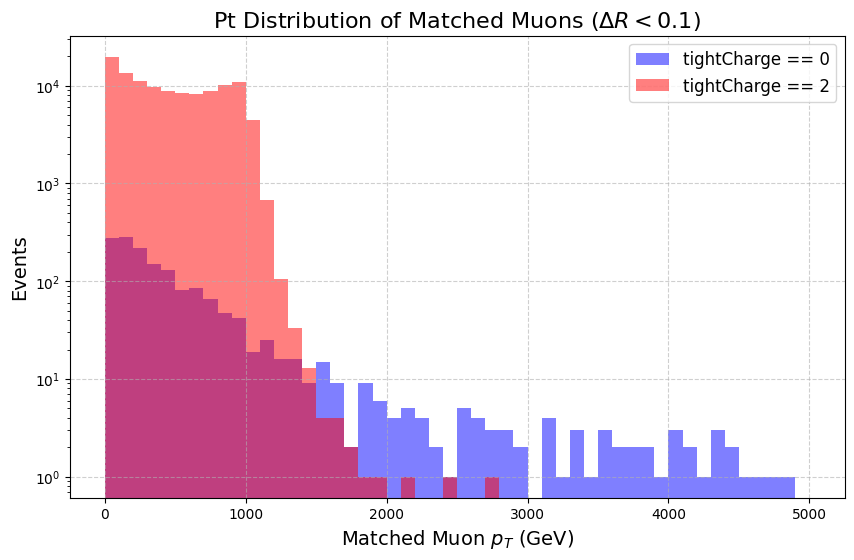

In [20]:
# 1. 4차원 벡터로 뮤온과 LHE 입자 구성
# (Vector의 Momentum4D 이름으로 등록해야 deltaR 계산이 쉬워집니다)
muons = ak.zip({
    "pt": events["Muon_pt"].array(),
    "eta": events["Muon_eta"].array(),
    "phi": events["Muon_phi"].array(),
    "mass": events["Muon_mass"].array(),
    "tightCharge": events["Muon_tightCharge"].array()
}, with_name="Momentum4D")

lhe_parts = ak.zip({
    "pt": events["LHEPart_pt"].array(),
    "eta": events["LHEPart_eta"].array(),
    "phi": events["LHEPart_phi"].array(),
    "mass": events["LHEPart_mass"].array(),
    "pdgId": events["LHEPart_pdgId"].array()
}, with_name="Momentum4D")

# 2. LHE 입자 중 뮤온(pdgId가 13이거나 -13)만 선택
lhe_muons = lhe_parts[abs(lhe_parts.pdgId) == 13]

# 3. 뮤온과 LHE 뮤온 간의 쌍 생성 (한 이벤트 안의 모든 가능한 조합)
# nested=True로 설정하면 기존 뮤온 배열 형태를 유지하면서 LHE 뮤온과 1:다 구조로 만들어줍니다.
pairs = ak.cartesian({"muon": muons, "lhe": lhe_muons}, nested=True)

# 4. 각 쌍에 대해 deltaR 계산
deltaR = pairs["muon"].deltaR(pairs["lhe"])

# 5. deltaR < 0.1 인 LHE 뮤온이 1개라도 존재하는 경우 (즉, 매칭된 일반 뮤온 찾기)
# axis=-1 (가장 안쪽 차원: LHE 뮤온) 방향으로 any()를 확인
is_matched_mask = ak.any(deltaR < 0.1, axis=-1)

# 6. 매칭된 뮤온만 남기기
matched_muons = muons[is_matched_mask]

# 7. 이제 여기서 tightCharge 값에 따라 나누기
muons_tc0 = matched_muons[matched_muons.tightCharge == 0]
muons_tc2 = matched_muons[matched_muons.tightCharge == 2]

# 8. pt 분포를 그리기 위해 내부 구조를 풀기(flatten)
pt_tc0 = ak.flatten(muons_tc0.pt)
pt_tc2 = ak.flatten(muons_tc2.pt)

# 9. Histogram(분포도) 그리기
plt.figure(figsize=(10, 6))

# pt 값의 범위나 bin 개수는 원하시는 줌에 맞게 조절하세요! (현재는 0~1000GeV 세팅)
# 갯수 차이가 클 수 있어 density 값에 관계 없이 직관적인 스케일을 위해 histtype='step' 등도 활용 가능합니다.
plt.hist(pt_tc0, bins=50, range=(0, 5000), alpha=0.5, label='tightCharge == 0', color='blue')
plt.hist(pt_tc2, bins=50, range=(0, 5000), alpha=0.5, label='tightCharge == 2', color='red')

plt.xlabel('Matched Muon $p_{T}$ (GeV)', fontsize=14)
plt.ylabel('Events', fontsize=14)
plt.title('Pt Distribution of Matched Muons ($\\Delta R < 0.1$)', fontsize=16)
plt.legend(fontsize=12)

# pt 분포는 편차가 커서 로그 스케일로 보는 것이 도움이 될 때가 많습니다.
# 선형 스케일로 보고 싶으시다면 아래 줄을 주석 처리 하시면 됩니다.
plt.yscale('log')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()


/tmp/ipykernel_355390/1001988772.py:21: RuntimeWarning: invalid value encountered in divide
  percent_tc0 = np.where(total_counts > 0, (counts_tc0 / total_counts) * 100, 0)
/tmp/ipykernel_355390/1001988772.py:22: RuntimeWarning: invalid value encountered in divide
  percent_tc2 = np.where(total_counts > 0, (counts_tc2 / total_counts) * 100, 0)


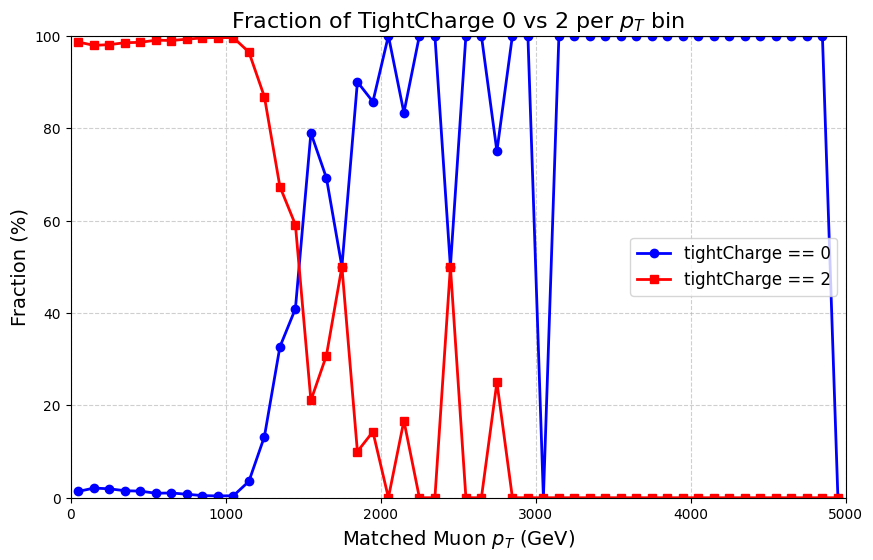

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Awkward 배열을 확실하게 순수 Numpy 배열로 변환
pt_tc0_np = ak.to_numpy(pt_tc0)
pt_tc2_np = ak.to_numpy(pt_tc2)

# 2. Histogram 구간(bin) 설정 (예: 0~1000까지 50개 구간)
bins = np.linspace(0, 5000, 51)
bin_centers = 0.5 * (bins[:-1] + bins[1:]) # 선 그래프의 x축 포인트

# 3. 각 구간별 뮤온 개수 계산
counts_tc0, _ = np.histogram(pt_tc0_np, bins=bins)
counts_tc2, _ = np.histogram(pt_tc2_np, bins=bins)

# 4. 각 bin의 총합(전체) 계산
total_counts = counts_tc0 + counts_tc2

# 5. np.where 하나로 '0으로 나누기 에러(ZeroDivision)' 방지 & 조건부 계산
# 전체 갯수가 0 초과일 때만 비율 계산을 수행하고, 아닐 때는 그냥 0을 넣습니다.
percent_tc0 = np.where(total_counts > 0, (counts_tc0 / total_counts) * 100, 0)
percent_tc2 = np.where(total_counts > 0, (counts_tc2 / total_counts) * 100, 0)

# 6. 비율 꺾은선 그래프 시각화
plt.figure(figsize=(10, 6))

# marker='o'(원) 나 's'(사각형) 등을 주면 데이터 포인트가 잘 보입니다.
plt.plot(bin_centers, percent_tc0, marker='o', label='tightCharge == 0', color='blue', linewidth=2)
plt.plot(bin_centers, percent_tc2, marker='s', label='tightCharge == 2', color='red', linewidth=2)

# 꾸미기
plt.xlim(bins[0], bins[-1])
plt.ylim(0, 100) # 백분율이므로 0~100 고정
plt.xlabel('Matched Muon $p_{T}$ (GeV)', fontsize=14)
plt.ylabel('Fraction (%)', fontsize=14)
plt.title('Fraction of TightCharge 0 vs 2 per $p_{T}$ bin', fontsize=16)

plt.legend(fontsize=12, loc='center right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()


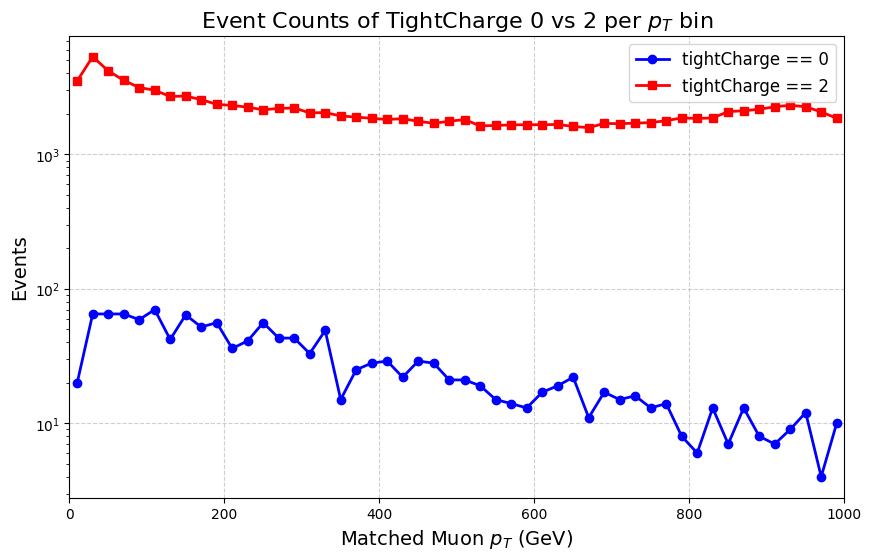

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Awkward 배열을 확실하게 순수 Numpy 배열로 변환
pt_tc0_np = ak.to_numpy(pt_tc0)
pt_tc2_np = ak.to_numpy(pt_tc2)

# 2. Histogram 구간(bin) 설정 (예: 0~1000까지 50개 구간)
bins = np.linspace(0, 1000, 51)
bin_centers = 0.5 * (bins[:-1] + bins[1:]) # 선 그래프의 x축 포인트

# 3. 각 구간별 뮤온 '개수' 직접 계산
counts_tc0, _ = np.histogram(pt_tc0_np, bins=bins)
counts_tc2, _ = np.histogram(pt_tc2_np, bins=bins)

# 4. 이벤트 개수 꺾은선 그래프 시각화
plt.figure(figsize=(10, 6))

# 퍼센트 대신 개수(counts_*)를 곧바로 입력합니다.
plt.plot(bin_centers, counts_tc0, marker='o', label='tightCharge == 0', color='blue', linewidth=2)
plt.plot(bin_centers, counts_tc2, marker='s', label='tightCharge == 2', color='red', linewidth=2)

# 꾸미기
plt.xlim(bins[0], bins[-1])
plt.xlabel('Matched Muon $p_{T}$ (GeV)', fontsize=14)
plt.ylabel('Events', fontsize=14)
plt.title('Event Counts of TightCharge 0 vs 2 per $p_{T}$ bin', fontsize=16)

plt.legend(fontsize=12, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

# 개수는 차이가 크므로 기본적으로 log 스케일로 보기 좋게 설정
plt.yscale('log') 
# (만약 선형 스케일로 보고 싶으시다면 위 코드를 주석 처리하시면 됩니다)

plt.show()


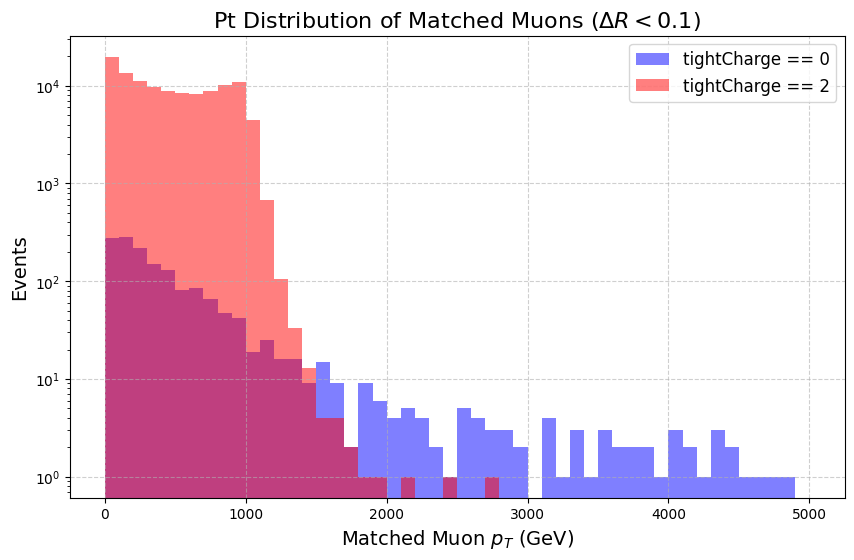

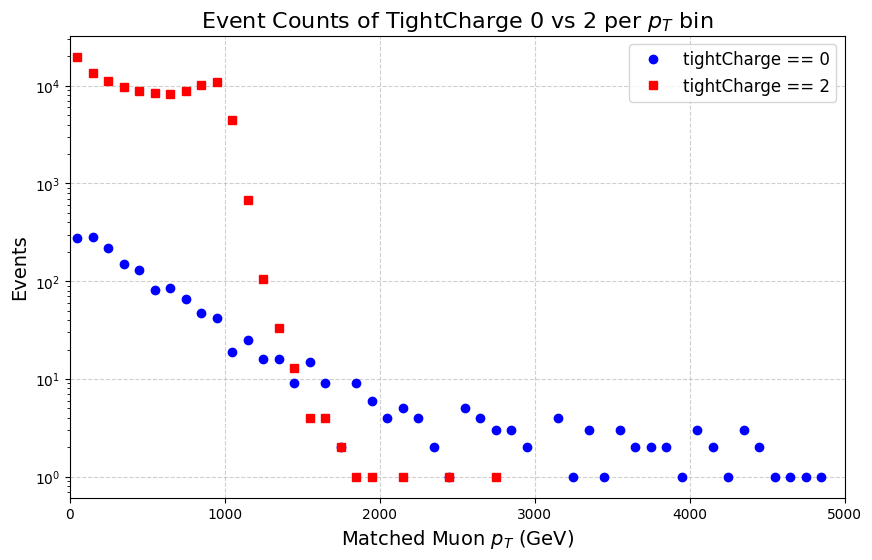

In [29]:

sample = "/gv0/Users/achihwan/SKNano/Run3NanoAODv12/2023/WRtoNMutoMuMuJJ_MWR2000_N100_TuneCP5_13p6TeV_madgraph-pythia8/NANOAODSIM/130X_mcRun3_2023_realistic_v15-v2/130000/c8f9b760-1932-4a95-b7d5-f836e3bb8b79.root"
file = uproot.open(sample)
events = file["Events"]
runs = file["Runs"]
keys = events.keys()

# 1. 4차원 벡터로 뮤온과 LHE 입자 구성
# (Vector의 Momentum4D 이름으로 등록해야 deltaR 계산이 쉬워집니다)
muons = ak.zip({
    "pt": events["Muon_pt"].array(),
    "eta": events["Muon_eta"].array(),
    "phi": events["Muon_phi"].array(),
    "mass": events["Muon_mass"].array(),
    "tightCharge": events["Muon_tightCharge"].array()
}, with_name="Momentum4D")

lhe_parts = ak.zip({
    "pt": events["LHEPart_pt"].array(),
    "eta": events["LHEPart_eta"].array(),
    "phi": events["LHEPart_phi"].array(),
    "mass": events["LHEPart_mass"].array(),
    "pdgId": events["LHEPart_pdgId"].array()
}, with_name="Momentum4D")

# 2. LHE 입자 중 뮤온(pdgId가 13이거나 -13)만 선택
lhe_muons = lhe_parts[abs(lhe_parts.pdgId) == 13]

# 3. 뮤온과 LHE 뮤온 간의 쌍 생성 (한 이벤트 안의 모든 가능한 조합)
# nested=True로 설정하면 기존 뮤온 배열 형태를 유지하면서 LHE 뮤온과 1:다 구조로 만들어줍니다.
pairs = ak.cartesian({"muon": muons, "lhe": lhe_muons}, nested=True)

# 4. 각 쌍에 대해 deltaR 계산
deltaR = pairs["muon"].deltaR(pairs["lhe"])

# 5. deltaR < 0.1 인 LHE 뮤온이 1개라도 존재하는 경우 (즉, 매칭된 일반 뮤온 찾기)
# axis=-1 (가장 안쪽 차원: LHE 뮤온) 방향으로 any()를 확인
is_matched_mask = ak.any(deltaR < 0.1, axis=-1)

# 6. 매칭된 뮤온만 남기기
matched_muons = muons[is_matched_mask]

# 7. 이제 여기서 tightCharge 값에 따라 나누기
muons_tc0 = matched_muons[matched_muons.tightCharge == 0]
muons_tc2 = matched_muons[matched_muons.tightCharge == 2]

# 8. pt 분포를 그리기 위해 내부 구조를 풀기(flatten)
pt_tc0 = ak.flatten(muons_tc0.pt)
pt_tc2 = ak.flatten(muons_tc2.pt)

# 9. Histogram(분포도) 그리기
plt.figure(figsize=(10, 6))

# pt 값의 범위나 bin 개수는 원하시는 줌에 맞게 조절하세요! (현재는 0~1000GeV 세팅)
# 갯수 차이가 클 수 있어 density 값에 관계 없이 직관적인 스케일을 위해 histtype='step' 등도 활용 가능합니다.
plt.hist(pt_tc0, bins=50, range=(0, 5000), alpha=0.5, label='tightCharge == 0', color='blue')
plt.hist(pt_tc2, bins=50, range=(0, 5000), alpha=0.5, label='tightCharge == 2', color='red')

plt.xlabel('Matched Muon $p_{T}$ (GeV)', fontsize=14)
plt.ylabel('Events', fontsize=14)
plt.title('Pt Distribution of Matched Muons ($\\Delta R < 0.1$)', fontsize=16)
plt.legend(fontsize=12)

# pt 분포는 편차가 커서 로그 스케일로 보는 것이 도움이 될 때가 많습니다.
# 선형 스케일로 보고 싶으시다면 아래 줄을 주석 처리 하시면 됩니다.
plt.yscale('log')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()
import numpy as np
import matplotlib.pyplot as plt

# 1. Awkward 배열을 확실하게 순수 Numpy 배열로 변환
pt_tc0_np = ak.to_numpy(pt_tc0)
pt_tc2_np = ak.to_numpy(pt_tc2)

# 2. Histogram 구간(bin) 설정 (예: 0~1000까지 50개 구간)
bins = np.linspace(0, 5000, 51)
bin_centers = 0.5 * (bins[:-1] + bins[1:]) # 선 그래프의 x축 포인트

# 3. 각 구간별 뮤온 '개수' 직접 계산
counts_tc0, _ = np.histogram(pt_tc0_np, bins=bins)
counts_tc2, _ = np.histogram(pt_tc2_np, bins=bins)

# 4. 이벤트 개수 꺾은선 그래프 시각화
plt.figure(figsize=(10, 6))

# 퍼센트 대신 개수(counts_*)를 곧바로 입력합니다.
plt.plot(bin_centers, counts_tc0, marker='o', linestyle='none', label='tightCharge == 0', color='blue')
plt.plot(bin_centers, counts_tc2, marker='s', linestyle='none', label='tightCharge == 2', color='red')


# 꾸미기
plt.xlim(bins[0], bins[-1])
plt.xlabel('Matched Muon $p_{T}$ (GeV)', fontsize=14)
plt.ylabel('Events', fontsize=14)
plt.title('Event Counts of TightCharge 0 vs 2 per $p_{T}$ bin', fontsize=16)

plt.legend(fontsize=12, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

# 개수는 차이가 크므로 기본적으로 log 스케일로 보기 좋게 설정
plt.yscale('log') 
# (만약 선형 스케일로 보고 싶으시다면 위 코드를 주석 처리하시면 됩니다)

plt.show()


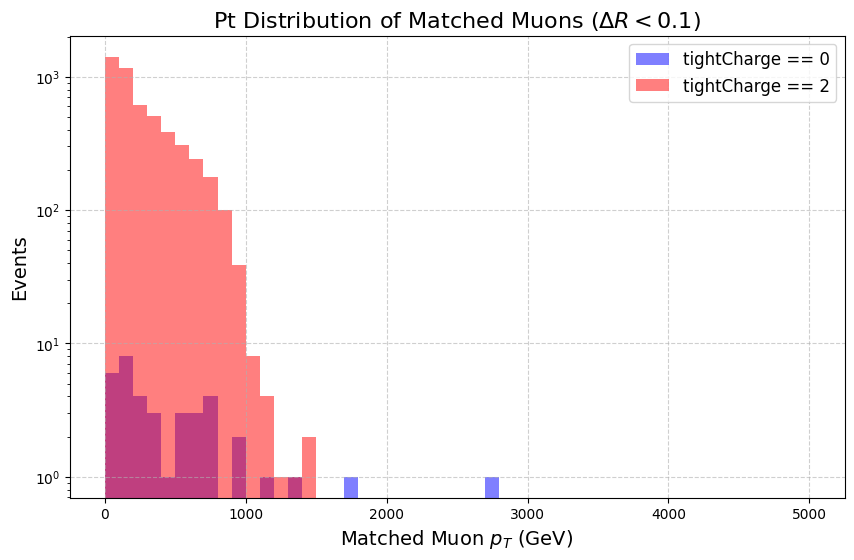

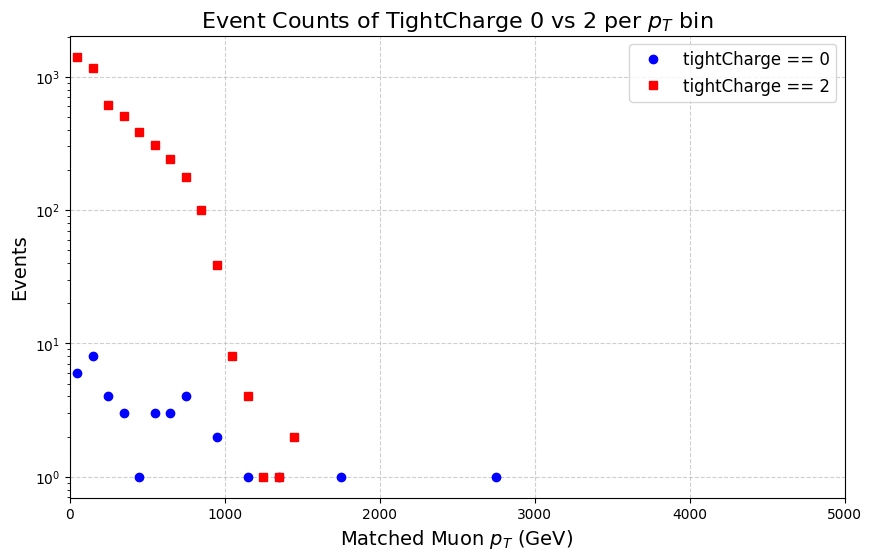

In [30]:

sample = "/gv0/Users/achihwan/SKNano/Run3NanoAODv12/2023/WRtoNMutoMuMuJJ_MWR2000_N1900_TuneCP5_13p6TeV_madgraph-pythia8/NANOAODSIM/130X_mcRun3_2023_realistic_v15-v2/2810000/5a39273d-6b59-421c-bab6-472c45c22a05.root"
file = uproot.open(sample)
events = file["Events"]
runs = file["Runs"]
keys = events.keys()

# 1. 4차원 벡터로 뮤온과 LHE 입자 구성
# (Vector의 Momentum4D 이름으로 등록해야 deltaR 계산이 쉬워집니다)
muons = ak.zip({
    "pt": events["Muon_pt"].array(),
    "eta": events["Muon_eta"].array(),
    "phi": events["Muon_phi"].array(),
    "mass": events["Muon_mass"].array(),
    "tightCharge": events["Muon_tightCharge"].array()
}, with_name="Momentum4D")

lhe_parts = ak.zip({
    "pt": events["LHEPart_pt"].array(),
    "eta": events["LHEPart_eta"].array(),
    "phi": events["LHEPart_phi"].array(),
    "mass": events["LHEPart_mass"].array(),
    "pdgId": events["LHEPart_pdgId"].array()
}, with_name="Momentum4D")

# 2. LHE 입자 중 뮤온(pdgId가 13이거나 -13)만 선택
lhe_muons = lhe_parts[abs(lhe_parts.pdgId) == 13]

# 3. 뮤온과 LHE 뮤온 간의 쌍 생성 (한 이벤트 안의 모든 가능한 조합)
# nested=True로 설정하면 기존 뮤온 배열 형태를 유지하면서 LHE 뮤온과 1:다 구조로 만들어줍니다.
pairs = ak.cartesian({"muon": muons, "lhe": lhe_muons}, nested=True)

# 4. 각 쌍에 대해 deltaR 계산
deltaR = pairs["muon"].deltaR(pairs["lhe"])

# 5. deltaR < 0.1 인 LHE 뮤온이 1개라도 존재하는 경우 (즉, 매칭된 일반 뮤온 찾기)
# axis=-1 (가장 안쪽 차원: LHE 뮤온) 방향으로 any()를 확인
is_matched_mask = ak.any(deltaR < 0.1, axis=-1)

# 6. 매칭된 뮤온만 남기기
matched_muons = muons[is_matched_mask]

# 7. 이제 여기서 tightCharge 값에 따라 나누기
muons_tc0 = matched_muons[matched_muons.tightCharge == 0]
muons_tc2 = matched_muons[matched_muons.tightCharge == 2]

# 8. pt 분포를 그리기 위해 내부 구조를 풀기(flatten)
pt_tc0 = ak.flatten(muons_tc0.pt)
pt_tc2 = ak.flatten(muons_tc2.pt)

# 9. Histogram(분포도) 그리기
plt.figure(figsize=(10, 6))

# pt 값의 범위나 bin 개수는 원하시는 줌에 맞게 조절하세요! (현재는 0~1000GeV 세팅)
# 갯수 차이가 클 수 있어 density 값에 관계 없이 직관적인 스케일을 위해 histtype='step' 등도 활용 가능합니다.
plt.hist(pt_tc0, bins=50, range=(0, 5000), alpha=0.5, label='tightCharge == 0', color='blue')
plt.hist(pt_tc2, bins=50, range=(0, 5000), alpha=0.5, label='tightCharge == 2', color='red')

plt.xlabel('Matched Muon $p_{T}$ (GeV)', fontsize=14)
plt.ylabel('Events', fontsize=14)
plt.title('Pt Distribution of Matched Muons ($\\Delta R < 0.1$)', fontsize=16)
plt.legend(fontsize=12)

# pt 분포는 편차가 커서 로그 스케일로 보는 것이 도움이 될 때가 많습니다.
# 선형 스케일로 보고 싶으시다면 아래 줄을 주석 처리 하시면 됩니다.
plt.yscale('log')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()
import numpy as np
import matplotlib.pyplot as plt

# 1. Awkward 배열을 확실하게 순수 Numpy 배열로 변환
pt_tc0_np = ak.to_numpy(pt_tc0)
pt_tc2_np = ak.to_numpy(pt_tc2)

# 2. Histogram 구간(bin) 설정 (예: 0~1000까지 50개 구간)
bins = np.linspace(0, 5000, 51)
bin_centers = 0.5 * (bins[:-1] + bins[1:]) # 선 그래프의 x축 포인트

# 3. 각 구간별 뮤온 '개수' 직접 계산
counts_tc0, _ = np.histogram(pt_tc0_np, bins=bins)
counts_tc2, _ = np.histogram(pt_tc2_np, bins=bins)

# 4. 이벤트 개수 꺾은선 그래프 시각화
plt.figure(figsize=(10, 6))

# 퍼센트 대신 개수(counts_*)를 곧바로 입력합니다.
plt.plot(bin_centers, counts_tc0, marker='o', linestyle='none', label='tightCharge == 0', color='blue')
plt.plot(bin_centers, counts_tc2, marker='s', linestyle='none', label='tightCharge == 2', color='red')


# 꾸미기
plt.xlim(bins[0], bins[-1])
plt.xlabel('Matched Muon $p_{T}$ (GeV)', fontsize=14)
plt.ylabel('Events', fontsize=14)
plt.title('Event Counts of TightCharge 0 vs 2 per $p_{T}$ bin', fontsize=16)

plt.legend(fontsize=12, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

# 개수는 차이가 크므로 기본적으로 log 스케일로 보기 좋게 설정
plt.yscale('log') 
# (만약 선형 스케일로 보고 싶으시다면 위 코드를 주석 처리하시면 됩니다)

plt.show()


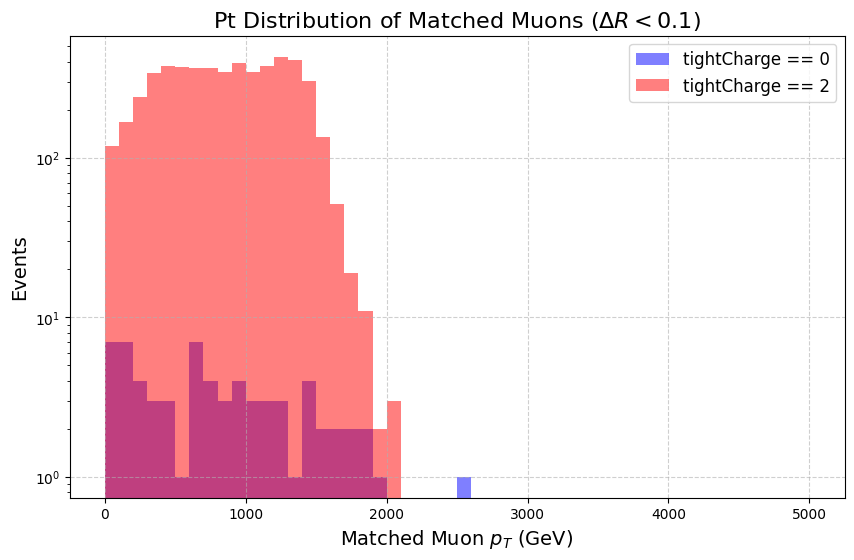

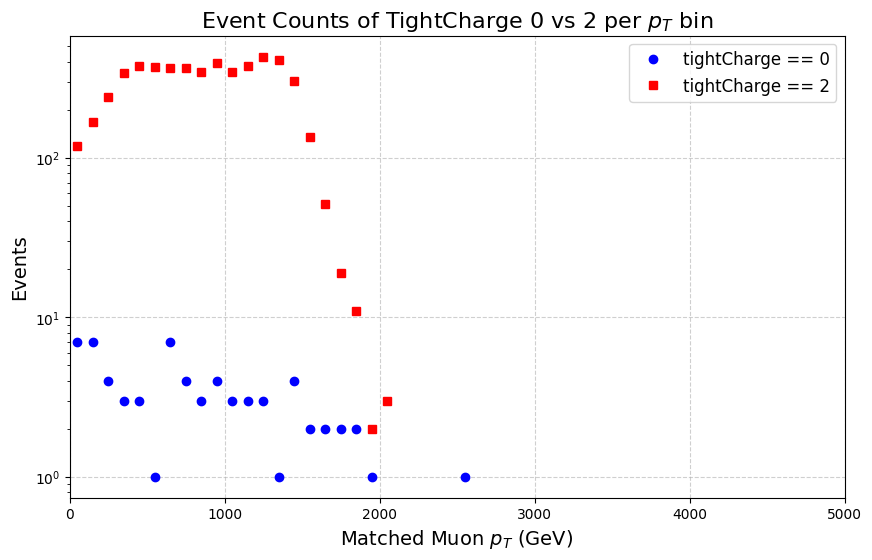

In [31]:

sample = "/gv0/Users/achihwan/SKNano/Run3NanoAODv12/2023/WRtoNMutoMuMuJJ_MWR4000_N2100_TuneCP5_13p6TeV_madgraph-pythia8/NANOAODSIM/130X_mcRun3_2023_realistic_v15-v2/130000/8a27eb63-eeed-4a82-97a2-145a839285c4.root"
file = uproot.open(sample)
events = file["Events"]
runs = file["Runs"]
keys = events.keys()

# 1. 4차원 벡터로 뮤온과 LHE 입자 구성
# (Vector의 Momentum4D 이름으로 등록해야 deltaR 계산이 쉬워집니다)
muons = ak.zip({
    "pt": events["Muon_pt"].array(),
    "eta": events["Muon_eta"].array(),
    "phi": events["Muon_phi"].array(),
    "mass": events["Muon_mass"].array(),
    "tightCharge": events["Muon_tightCharge"].array()
}, with_name="Momentum4D")

lhe_parts = ak.zip({
    "pt": events["LHEPart_pt"].array(),
    "eta": events["LHEPart_eta"].array(),
    "phi": events["LHEPart_phi"].array(),
    "mass": events["LHEPart_mass"].array(),
    "pdgId": events["LHEPart_pdgId"].array()
}, with_name="Momentum4D")

# 2. LHE 입자 중 뮤온(pdgId가 13이거나 -13)만 선택
lhe_muons = lhe_parts[abs(lhe_parts.pdgId) == 13]

# 3. 뮤온과 LHE 뮤온 간의 쌍 생성 (한 이벤트 안의 모든 가능한 조합)
# nested=True로 설정하면 기존 뮤온 배열 형태를 유지하면서 LHE 뮤온과 1:다 구조로 만들어줍니다.
pairs = ak.cartesian({"muon": muons, "lhe": lhe_muons}, nested=True)

# 4. 각 쌍에 대해 deltaR 계산
deltaR = pairs["muon"].deltaR(pairs["lhe"])

# 5. deltaR < 0.1 인 LHE 뮤온이 1개라도 존재하는 경우 (즉, 매칭된 일반 뮤온 찾기)
# axis=-1 (가장 안쪽 차원: LHE 뮤온) 방향으로 any()를 확인
is_matched_mask = ak.any(deltaR < 0.1, axis=-1)

# 6. 매칭된 뮤온만 남기기
matched_muons = muons[is_matched_mask]

# 7. 이제 여기서 tightCharge 값에 따라 나누기
muons_tc0 = matched_muons[matched_muons.tightCharge == 0]
muons_tc2 = matched_muons[matched_muons.tightCharge == 2]

# 8. pt 분포를 그리기 위해 내부 구조를 풀기(flatten)
pt_tc0 = ak.flatten(muons_tc0.pt)
pt_tc2 = ak.flatten(muons_tc2.pt)

# 9. Histogram(분포도) 그리기
plt.figure(figsize=(10, 6))

# pt 값의 범위나 bin 개수는 원하시는 줌에 맞게 조절하세요! (현재는 0~1000GeV 세팅)
# 갯수 차이가 클 수 있어 density 값에 관계 없이 직관적인 스케일을 위해 histtype='step' 등도 활용 가능합니다.
plt.hist(pt_tc0, bins=50, range=(0, 5000), alpha=0.5, label='tightCharge == 0', color='blue')
plt.hist(pt_tc2, bins=50, range=(0, 5000), alpha=0.5, label='tightCharge == 2', color='red')

plt.xlabel('Matched Muon $p_{T}$ (GeV)', fontsize=14)
plt.ylabel('Events', fontsize=14)
plt.title('Pt Distribution of Matched Muons ($\\Delta R < 0.1$)', fontsize=16)
plt.legend(fontsize=12)

# pt 분포는 편차가 커서 로그 스케일로 보는 것이 도움이 될 때가 많습니다.
# 선형 스케일로 보고 싶으시다면 아래 줄을 주석 처리 하시면 됩니다.
plt.yscale('log')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()
import numpy as np
import matplotlib.pyplot as plt

# 1. Awkward 배열을 확실하게 순수 Numpy 배열로 변환
pt_tc0_np = ak.to_numpy(pt_tc0)
pt_tc2_np = ak.to_numpy(pt_tc2)

# 2. Histogram 구간(bin) 설정 (예: 0~1000까지 50개 구간)
bins = np.linspace(0, 5000, 51)
bin_centers = 0.5 * (bins[:-1] + bins[1:]) # 선 그래프의 x축 포인트

# 3. 각 구간별 뮤온 '개수' 직접 계산
counts_tc0, _ = np.histogram(pt_tc0_np, bins=bins)
counts_tc2, _ = np.histogram(pt_tc2_np, bins=bins)

# 4. 이벤트 개수 꺾은선 그래프 시각화
plt.figure(figsize=(10, 6))

# 퍼센트 대신 개수(counts_*)를 곧바로 입력합니다.
plt.plot(bin_centers, counts_tc0, marker='o', linestyle='none', label='tightCharge == 0', color='blue')
plt.plot(bin_centers, counts_tc2, marker='s', linestyle='none', label='tightCharge == 2', color='red')


# 꾸미기
plt.xlim(bins[0], bins[-1])
plt.xlabel('Matched Muon $p_{T}$ (GeV)', fontsize=14)
plt.ylabel('Events', fontsize=14)
plt.title('Event Counts of TightCharge 0 vs 2 per $p_{T}$ bin', fontsize=16)

plt.legend(fontsize=12, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

# 개수는 차이가 크므로 기본적으로 log 스케일로 보기 좋게 설정
plt.yscale('log') 
# (만약 선형 스케일로 보고 싶으시다면 위 코드를 주석 처리하시면 됩니다)

plt.show()
